In [1]:
import ipywidgets as widgets
from IPython.display import display
import os

box_layout = widgets.Layout(
    display="flex",
    flex_flow="column",
    align_items="center",
    border="1px solid #E0E0E0",
    width="400px",
    padding="25px",
    border_radius="10px"
)

button_layout = widgets.Layout(width="100%", height="40px")

upload_layout = widgets.Layout(width="100%")

title = widgets.HTML(
    "<h3 style='margin-bottom:10px;'>Upload CSV Files 👇</h3>"
)

subtitle = widgets.HTML(
    "<p style='color:gray; margin-top:0;'>Select one or more CSV files to upload and save</p>"
)

train_uploader = widgets.FileUpload(
    accept='.csv',
    multiple=True,
    layout=upload_layout
)

save_button = widgets.Button(
    description='Save Files',
    button_style='primary',
    icon='save',
    layout=button_layout
)

status = widgets.HTML("<p style='color:gray;'>Waiting for upload...</p>")

output = widgets.Output()

def save_files(change=None):
    with output:
        output.clear_output()
        
        if train_uploader.value:
            saved_files = []
            for filename, file_info in train_uploader.value.items():
                with open(filename, "wb") as f:
                    f.write(file_info['content'])
                saved_files.append(filename)
            
            status.value = f"<p style='color:green;'>Saved {len(saved_files)} file(s) 👍</p>"
        else:
            status.value = "<p style='color:red;'>⚠️ No files uploaded yet</p>"

train_uploader.observe(save_files, names='value')

save_button.on_click(save_files)

card = widgets.VBox(
    [title, subtitle, train_uploader, save_button, status],
    layout=box_layout
)

display(card)
display(output)

Output()

In [2]:
import numpy as np
import pandas as pd
import seaborn as sb

In [3]:
df = pd.read_csv('file.csv')

In [4]:
df.shape

(1000, 3)

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
959,6.76,27.0,1
322,6.77,38.0,1
345,6.26,13.0,1
595,6.13,7.0,1
560,7.11,67.0,0


<Axes: xlabel='cgpa', ylabel='Density'>

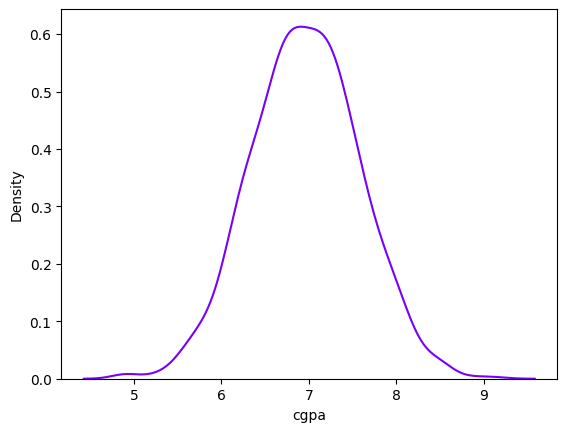

In [6]:
sb.kdeplot(data=df['cgpa'], color="#7700ff")

#### **Above graph is normally distributed**

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

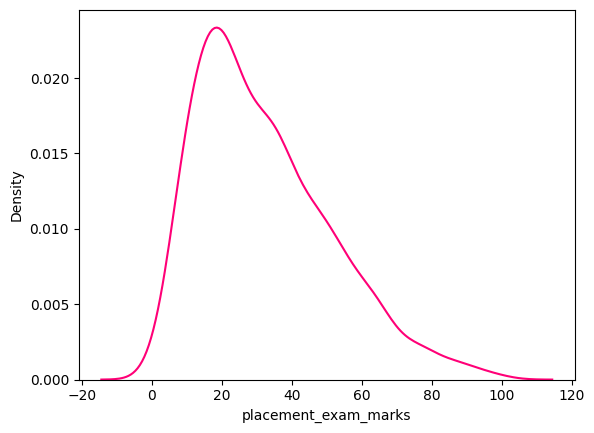

In [7]:
sb.kdeplot(data=df['placement_exam_marks'], color="#ff0077")

#### **Above graph is right skewed**

In [8]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961240
std,0.615898
min,4.890000
25%,6.550000
50%,6.960000
75%,7.370000
max,9.120000


### **Finding boundary values**

In [9]:
print(f"Upper limit: {(df['cgpa'].mean() + 3 * df['cgpa'].std()).__round__(3)}")
print(f"Lower limit: {(df['cgpa'].mean() - 3 * df['cgpa'].std()).__round__(3)}")

Upper limit: 8.809
Lower limit: 5.114


### **Outliers**

In [10]:
df[(df['cgpa'] > 8.809) | (df['cgpa'] < 5.114)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### **Trimming**

#### **Z score implementation**

In [11]:
df['zscores'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [12]:
df.sample(5)

,cgpa,placement_exam_marks,placed,zscores
834,6.22,52.0,1,-1.203511
9,7.75,94.0,1,1.280667
499,6.42,31.0,0,-0.878782
217,6.92,16.0,0,-0.066959
716,7.06,19.0,1,0.160351


In [13]:
df[df['zscores'] > 3]

,cgpa,placement_exam_marks,placed,zscores
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [14]:
df[df['zscores'] < -3]

,cgpa,placement_exam_marks,placed,zscores
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [15]:
new_df = df[(df['zscores']<3) & (df['zscores']>-3)]

### **Results**

In [16]:
new_df.shape

(995, 4)

### **Capping**

In [17]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

In [18]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,     # condition
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [19]:
df.shape

(1000, 4)